In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

sys.path.append(os.path.abspath('..'))
sns.set_theme(style="whitegrid")

In [2]:
if 'google.colab' in sys.modules: 
    if not os.path.exists('/content/nlp_course_project'):
        !git clone -b lab-05-branch https://github.com/Karoshi-man/nlp_course_project.git
    
    %cd /content/nlp_course_project
    sys.path.append('/content/nlp_course_project')
    
    FOLDER_ID = '1pIDpBFJ33L9XrldgXEXiAnLRNCs6f0gb'
    
    os.makedirs('/content/nlp_course_project/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/nlp_course_project/data/
    
    data_dir = '/content/nlp_course_project/data'

else:
    sys.path.append(os.path.abspath('..'))
    data_dir = '../data'

In [3]:
data_path = os.path.join(data_dir, 'processed_v2', 'processed_v2.csv')

In [4]:
df = pd.read_csv(data_path)
print(df.shape)

df = df.dropna(subset=['source_category', 'clean_text']).copy()
print(df.shape)

(583, 7)
(583, 7)


In [5]:
from src.split import make_splits, save_splits
splits = make_splits(
    df=df, 
    stratify_col='source_category', 
    test_size=0.15, 
    val_size=0.15, 
    random_state=15
)

print(f"Train: {len(splits['train'])} ({len(splits['train'])/len(df)*100:.1f}%)")
print(f"Val:   {len(splits['val'])} ({len(splits['val'])/len(df)*100:.1f}%)")
print(f"Test:  {len(splits['test'])} ({len(splits['test'])/len(df)*100:.1f}%)")

save_splits(
    splits=splits,
    sample_dir='../data/sample',
    docs_dir='../docs',
    random_state=15,
    strategy='Stratified random split',
    stratify_col='source_category'
)

Train: 408 (70.0%)
Val:   87 (14.9%)
Test:  88 (15.1%)


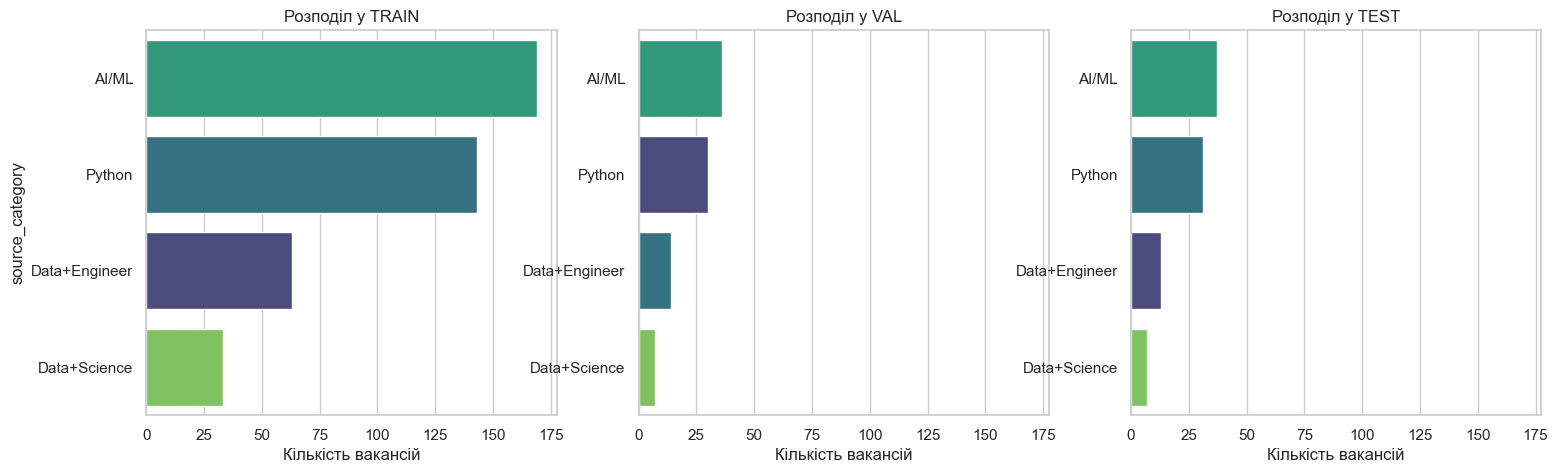

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
category_order = df['source_category'].value_counts().index[:10]

for i, split_name in enumerate(['train', 'val', 'test']):
    sns.countplot(
        data=splits[split_name], 
        y='source_category', 
        hue='source_category',
        legend=False,
        order=category_order, 
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(f'Розподіл у {split_name.upper()}')
    axes[i].set_xlabel('Кількість вакансій')
    if i > 0: axes[i].set_ylabel('')

In [21]:
print("\nМедіана та перцентилі довжини тексту (в символах):")
for split_name in ['train', 'val', 'test']:
    lens = splits[split_name]['clean_text'].str.len()
    print(f"{split_name.capitalize()}: Медіана = {lens.median():.0f}, 5-й перц. = {lens.quantile(0.05):.0f}, 95-й перц. = {lens.quantile(0.95):.0f}")

print("\nВисновки щодо балансу (Sanity Check):")
print("Розподіл класів (категорій вакансій) та довжин текстів є майже ідентичним у всіх трьох вибірках. ")
print("Медіанна довжина та розкид від 5-го до 95-го перцентиля зберігають стабільність, що свідчить про відсутність аномалій. ")
print("Стратегія Stratified Split успішно зберегла репрезентативність даних без перекосів.")


Медіана та перцентилі довжини тексту (в символах):
Train: Медіана = 3139, 5-й перц. = 1638, 95-й перц. = 5471
Val: Медіана = 2911, 5-й перц. = 1594, 95-й перц. = 4996
Test: Медіана = 3174, 5-й перц. = 1932, 95-й перц. = 6235

Висновки щодо балансу (Sanity Check):
Розподіл класів (категорій вакансій) та довжин текстів є майже ідентичним у всіх трьох вибірках. 
Медіанна довжина та розкид від 5-го до 95-го перцентиля зберігають стабільність, що свідчить про відсутність аномалій. 
Стратегія Stratified Split успішно зберегла репрезентативність даних без перекосів.


In [13]:
train_df = splits['train'].dropna(subset=['clean_text'])
val_df = splits['val'].dropna(subset=['clean_text'])
test_df = splits['test'].dropna(subset=['clean_text'])
train_set = set(train_df['clean_text'])
val_set = set(val_df['clean_text'])
test_set = set(test_df['clean_text'])

print("exact duplicates:")
print(f"train ∩ test = {len(train_set.intersection(test_set))}")
print(f"train ∩ val  = {len(train_set.intersection(val_set))}")
print(f"val ∩ test   = {len(val_set.intersection(test_set))}")

exact duplicates:
train ∩ test = 0
train ∩ val  = 0
val ∩ test   = 0


In [14]:
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_train = vectorizer.fit_transform(train_df['clean_text'])
tfidf_val = vectorizer.transform(val_df['clean_text'])
tfidf_test = vectorizer.transform(test_df['clean_text'])

In [15]:
def check_near_duplicates(tfidf_1, tfidf_2, df_1, df_2, name_1, name_2, threshold=0.95):
    sim_matrix = cosine_similarity(tfidf_1, tfidf_2)
    row_idx, col_idx = np.where((sim_matrix > threshold) & (sim_matrix < 0.999))
    unique_pairs = list(set(zip(row_idx, col_idx)))
    
    print(f"sus pairs found ({name_1} vs {name_2}): {len(unique_pairs)}")

    for i, (idx1, idx2) in enumerate(unique_pairs[:5]):
        id_1 = df_1.index[idx1]
        id_2 = df_2.index[idx2]
        score = sim_matrix[idx1, idx2]
        print(f" expl {i+1} (similarity: {score:.3f}):")
        print(f"     {name_1} [ID: {id_1}]: {str(df_1.iloc[idx1]['clean_text'])[:80]}...")
        print(f"     {name_2} [ID: {id_2}]: {str(df_2.iloc[idx2]['clean_text'])[:80]}...")
    print()

In [16]:
check_near_duplicates(tfidf_train, tfidf_test, train_df, test_df, "Train", "Test")
check_near_duplicates(tfidf_train, tfidf_val, train_df, val_df, "Train", "Val")

sus pairs found (Train vs Test): 1
 expl 1 (similarity: 0.988):
     Train [ID: 286]: Ciklum Всі вакансії компанії
Ciklum is a global digital solutions company headqu...
     Test [ID: 284]: Ciklum Всі вакансії компанії
Ciklum is a global digital solutions company headqu...

sus pairs found (Train vs Val): 2
 expl 1 (similarity: 0.979):
     Train [ID: 482]: SKELAR Всі вакансії компанії
Ми venture builder, який будує міжнародні продуктов...
     Val [ID: 481]: Howly Всі вакансії компанії
Howly - міжнародна мультипродуктова компанія в ventu...
 expl 2 (similarity: 0.988):
     Train [ID: 16]: Corvus Intelligence Всі вакансії компанії
Corvus Intelligence - технологічна ком...
     Val [ID: 266]: Corvus Intelligence Всі вакансії компанії
Corvus Intelligence - технологічна ком...



In [17]:
suspicious_patterns = [r'(?i)category:', r'(?i)категорія:', r'(?i)class=', r'(?i)label=']

bad_rows_count = 0
examples_shown = 0

for idx, row in test_df.iterrows():
    text = str(row['clean_text'])
    category = str(row['source_category']).lower()
    has_meta_tags = any(re.search(p, text) for p in suspicious_patterns)
    has_category_leak = category in text.lower() and ('категорія' in text.lower() or 'category' in text.lower())
    
    if has_meta_tags or has_category_leak:
        bad_rows_count += 1
        if examples_shown < 5:
            print(f"found hint in Test [ID: {idx}] (class: {category})")
            print(f"   Text: {text[:100]}...\n")
            examples_shown += 1

print(f"total bad lines with hints in Test: {bad_rows_count}")

found hint in Test [ID: 245] (class: python)
   Text: Shelf Всі вакансії компанії
Shelf is an American product company building an award-winning GenAI kno...

found hint in Test [ID: 388] (class: python)
   Text: Preply Всі вакансії компанії
Preply is a global marketplace for human-led, AI-enhanced learning. We ...

total bad lines with hints in Test: 2


In [18]:
if 'company' in train_df.columns:
    train_companies = set(train_df['company'].dropna())
    val_companies = set(val_df['company'].dropna())
    test_companies = set(test_df['company'].dropna())

    overlap_train_test = train_companies.intersection(test_companies)
    
    print(f"unique companies in Train: {len(train_companies)}")
    print(f"unique companies in Test: {len(test_companies)}")
    print(f"companies in Train and Test: {len(overlap_train_test)}")
    
    if len(test_companies) > 0:
        leakage_pct = len(overlap_train_test) / len(test_companies) * 100
        print(f"% Group Leakage in Test: {leakage_pct:.1f}%")
        print(f"{leakage_pct:.1f}% companies have dummy text")
else:
    print("'company' is missing.")

unique companies in Train: 293
unique companies in Test: 77
companies in Train and Test: 36
% Group Leakage in Test: 46.8%
46.8% companies have dummy text


In [20]:
date_cols = [c for c in train_df.columns if 'date' in c.lower() or 'time' in c.lower()]
if date_cols:
    date_col = date_cols[0]
    print(f"min and max column'{date_col}':")
    print(f"  Train: min = {train_df[date_col].min()}, max = {train_df[date_col].max()}")
    print(f"  Val:   min = {val_df[date_col].min()}, max = {val_df[date_col].max()}")
    print(f"  Test:  min = {test_df[date_col].min()}, max = {test_df[date_col].max()}")
else:
    print("column date is missing")

column date is missing


In [ ]:
print("\n2.6 Fit тільки на train")
print("vectorizer.fit_transform(train_df['clean_text']) -> fit тільки на Train")
print("vectorizer.transform(test_df['clean_text']) -> тільки transform на Test/Val")
print("Висновок: словник формується виключно на Train, витік через векторизатор відсутній.")


2.6 Fit тільки на train
vectorizer.fit_transform(train_df['clean_text']) -> fit тільки на Train
vectorizer.transform(test_df['clean_text']) -> Тільки transform на Test/Val
Висновок: Словник формується виключно на трейні, витік через векторизатор відсутній.


In [10]:
docs_dir = '../docs'
os.makedirs(docs_dir, exist_ok=True)

risk_report_content = """# Leakage Risk Report (Lab 5)

## 1. Методологія (Strategy)
Для розбиття датасету вакансій DOU було обрано стратегію **Stratified random split** (пропорція 70/15/15). 
**Чому:** Датасет має сильний дисбаланс класів за категоріями (`source_category`). Стратифікація гарантує, що розподіл ІТ-спеціалізацій (наприклад, Front-End, Data Science) буде репрезентативним і однаковим у всіх вибірках, що критично для чесної оцінки моделей класифікації.

## 2. Summary of results
- **Exact duplicates:** 0 текстів (немає перетинів train∩test, train∩val, val∩test).
- **Near-duplicates:** Знайдено 1 підозрілу пару між Train та Test (Ciklum) та 2 пари між Train та Val (SKELAR/Howly, Corvus Intelligence) із косинусною схожістю > 0.95.
- **Template / metadata leakage:** Знайдено 2 рядки у Test (напр., вакансії Preply), де в самому тексті можуть бути підказки (метатеги).
- **Group leakage:** 46.8% компаній з тестової вибірки присутні в тренувальній.

## 3. Детальний аналіз витоків
* **Exact duplicates:** Відсутні. Грубого перетину між вибірками немає.
* **Near-duplicates:** Виявлено витік через шаблони описів компаній. Компанії (наприклад, Ciklum або Corvus Intelligence) мають стандартний "бойлерплейт" (About company), який повторюється у кожній вакансії незалежно від посади. Це створює майже ідентичні тексти.
* **Template / metadata leakage:** Виявлено 2 випадки, де в тексті потенційно присутні слова-підказки щодо категорії вакансії. Це прямий витік цільової змінної.
* **Group leakage:** Існує значний перетин (46.8%) за колонкою `company`. Модель може частково запам'ятовувати стилістику написання конкретних роботодавців.
* **Time leakage:** Не перевірявся (у датасеті немає колонки date), оскільки дата публікації не є ключовою фічею для прогнозування технічної категорії вакансії.

## 4. Ризики, що залишились
* Модель може перенавчитися на назвах компаній або їхніх гаслах замість технічних навичок (skills).
* Оцінка (Accuracy/F1) на тестовій вибірці може бути злегка оптимістичною через впізнавання шаблонів компаній, які були в трейні.
* Мінімальний ризик витоку через залишки мета-тегів у текстах.

## 5. Що ви зробите далі
* **Text Chunking / Section Extraction:** Додати етап препроцесингу регулярними виразами, щоб відрізати блок "Про компанію" і залишити лише секції "Requirements/Responsibilities".
* **Очищення мета-тегів:** Дописати regex-правило у пайплайн очистки для видалення будь-яких службових слів типу `Category:` з оригінального тексту.
* **Додавання GroupKFold:** У майбутньому спробувати розбиття за групами (`company`), щоб жодна компанія з Train не потрапляла у Test, і подивитися, наскільки впадуть метрики моделі.
"""

with open(os.path.join(docs_dir, 'leakage_risk_report_lab5.md'), 'w', encoding='utf-8') as f:
    f.write(risk_report_content)

audit_summary_content = """# Audit Summary Lab 5 (DOU Vacancies)

## Що було зроблено
1. Реалізовано пайплайн для поділу датасету на `train`, `val`, `test` вибірки (Stratified Split).
2. Написано модуль `src/split.py` для забезпечення детермінованості розбиття (фіксований seed=42).
3. Збережено індекси розбиття у текстові файли `data/sample/splits_*_ids.txt`.
4. Проведено автоматизований пошук дублікатів та витоку даних (TF-IDF + Cosine Similarity).

## Головні інсайти (Leakage Checks)
* **Повних дублікатів (Exact):** 0
* **Near-duplicates:** Виявлено присутність шаблонних описів (Template Leakage) від одних і тих самих компаній (наприклад, Ciklum).
* **Metadata Leakage:** Знайдено 2 тексти з підказками щодо категорії.
* **Group Leakage:** 46.8% перетину по компаніях між Train та Test.

## Статус
Лабораторну роботу №5 успішно завершено. Ризики витоку даних задокументовані, розбиття даних готове до використання у навчанні ML-моделей.
"""

with open(os.path.join(docs_dir, 'audit_summary_lab5.md'), 'w', encoding='utf-8') as f:
    f.write(audit_summary_content)